# 01 - Data Exploration

Explores whichever dataset is available under `data/` via the discovery pipeline (`src/data/dataset.py`). Defaults to the synthetic dataset generated by `scripts/generate_demo_data.py` if a real RID copy is not present under `data/raw/`.

Figures are saved to `results/figures/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from src.data.dataset import RoofDataset, discover_dataset_root
from src.data.stats import compute_dataset_stats
from src.data.splits import load_splits
from src.visualization.plotting import plot_sample_overview, save_figure

DATASET_ROOT = Path('../data/processed/synthetic')
SPLITS_DIR = Path('../data/splits')
FIG_DIR = Path('../results/figures')

layout = discover_dataset_root(DATASET_ROOT)
print('Dataset layout discovered:')
for k, v in layout.items():
    print(f'  {k}: {v}')

Dataset layout discovered:
  root: ..\data\processed\synthetic
  images: ..\data\processed\synthetic\images
  segments: ..\data\processed\synthetic\masks_segments
  superstructures: ..\data\processed\synthetic\masks_superstructures
  metadata: ..\data\processed\synthetic\metadata


In [2]:
splits = load_splits(SPLITS_DIR)
for name, ids in splits.items():
    print(f'{name}: {len(ids)} samples')

dataset = RoofDataset(DATASET_ROOT, splits['train'] + splits['val'] + splits['test'], transform=None)
print(f'\nTotal discovered samples: {len(dataset)}')

train: 84 samples
val: 18 samples
test: 18 samples

Total discovered samples: 120


## Dataset statistics

Image dimensions, per-class pixel counts, roof/obstacle pixel fractions.

In [3]:
stats = compute_dataset_stats(dataset)
summary = stats.summary()
for k, v in summary.items():
    print(f'{k}: {v}')

num_samples: 120
mean_image_size: [256.0, 256.0]
unique_image_sizes: [(256, 256)]
segment_class_pixel_counts: {'background': 5921653, 'N': 114738, 'S': 112292, 'flat': 703001, 'NE': 174967, 'SE': 225068, 'SW': 179465, 'NW': 226344, 'E': 104547, 'W': 102245}
superstructure_class_pixel_counts: {'background': 7590648, 'pvmodule': 50079, 'chimney': 49803, 'window': 61583, 'dormer': 88809, 'shadow': 3508, 'ladder': 7711, 'tree': 12179}
mean_roof_pixel_fraction: 0.24702288309733073
mean_obstacle_pixel_fraction: 0.0347991943359375


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = stats.segment_class_pixel_counts
axes[0].bar(seg_counts.keys(), seg_counts.values(), color='steelblue')
axes[0].set_title('Roof-segment class pixel counts')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log')

obs_counts = stats.superstructure_class_pixel_counts
axes[1].bar(obs_counts.keys(), obs_counts.values(), color='indianred')
axes[1].set_title('Superstructure class pixel counts')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_yscale('log')

fig.tight_layout()
save_figure(fig, FIG_DIR / 'class_distribution.png')
plt.show()

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(stats.roof_pixel_fraction_per_image, bins=15, color='seagreen')
ax[0].set_title('Roof pixel fraction per image')
ax[1].hist(stats.obstacle_pixel_fraction_per_image, bins=15, color='darkorange')
ax[1].set_title('Obstacle pixel fraction per image')
fig.tight_layout()
save_figure(fig, FIG_DIR / 'pixel_fraction_histograms.png')
plt.show()

## Sample visualizations

A few representative samples: input image, roof-segment mask, superstructure mask, combined overlay.

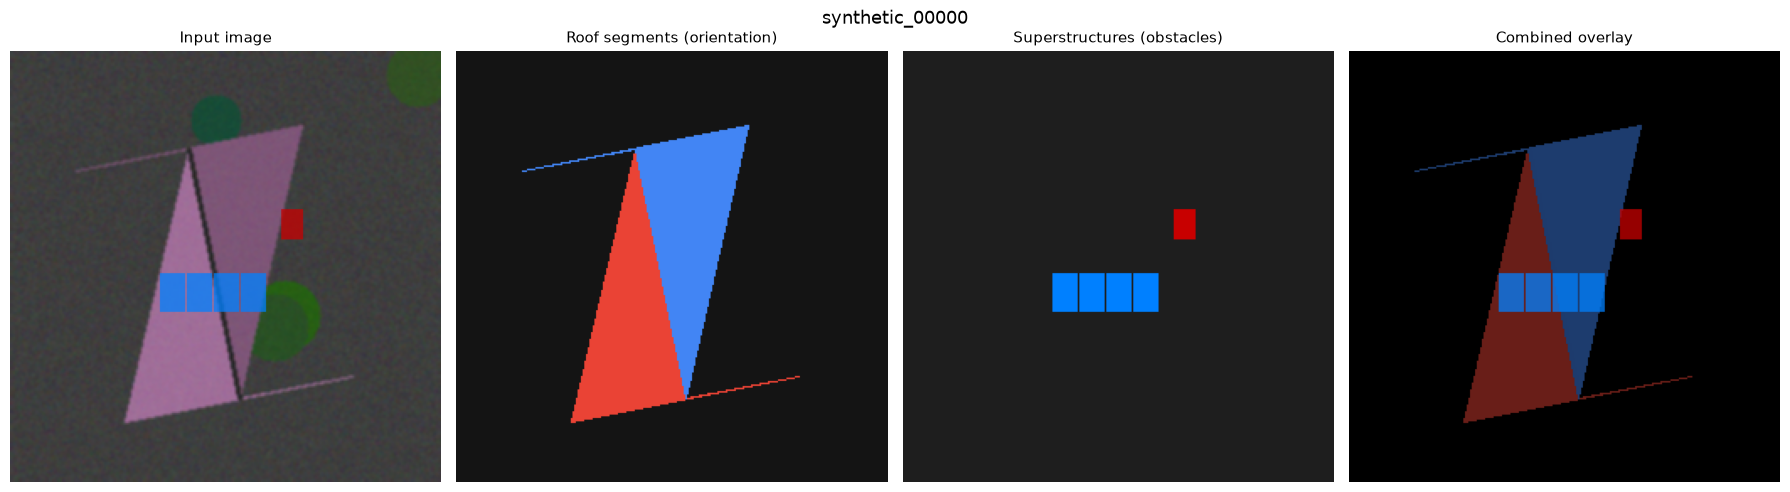

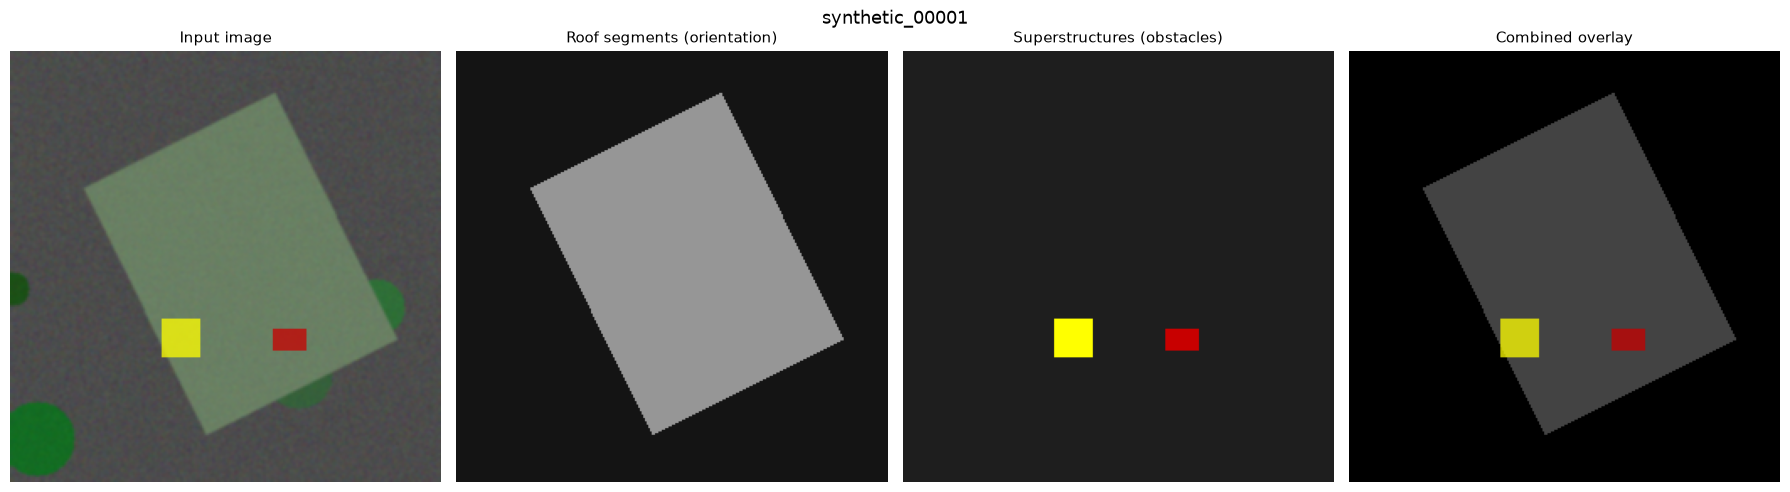

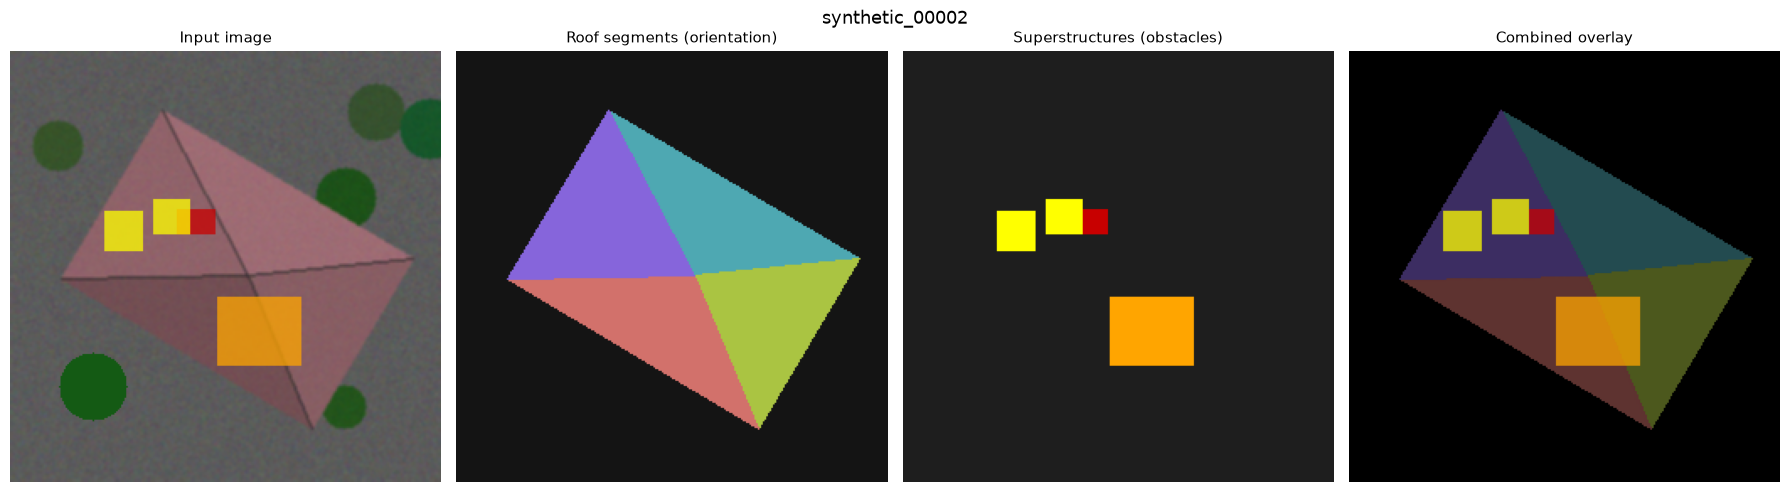

In [6]:
for i in range(3):
    item = dataset[i]
    fig = plot_sample_overview(
        item['image'].permute(1, 2, 0).numpy() if hasattr(item['image'], 'permute') else item['image'],
        item['segment_mask'].numpy(), item['superstructure_mask'].numpy(),
        title=item['sample_id'],
    )
    plt.show()

## Difficult examples

Samples with the highest obstacle-to-roof pixel ratio are the most geometrically challenging for usable-area estimation (most obstacle clearance area relative to available roof).

Top 3 most obstacle-dense samples (hardest for usable-area estimation):
  synthetic_00055: obstacle/roof pixel ratio = 0.511


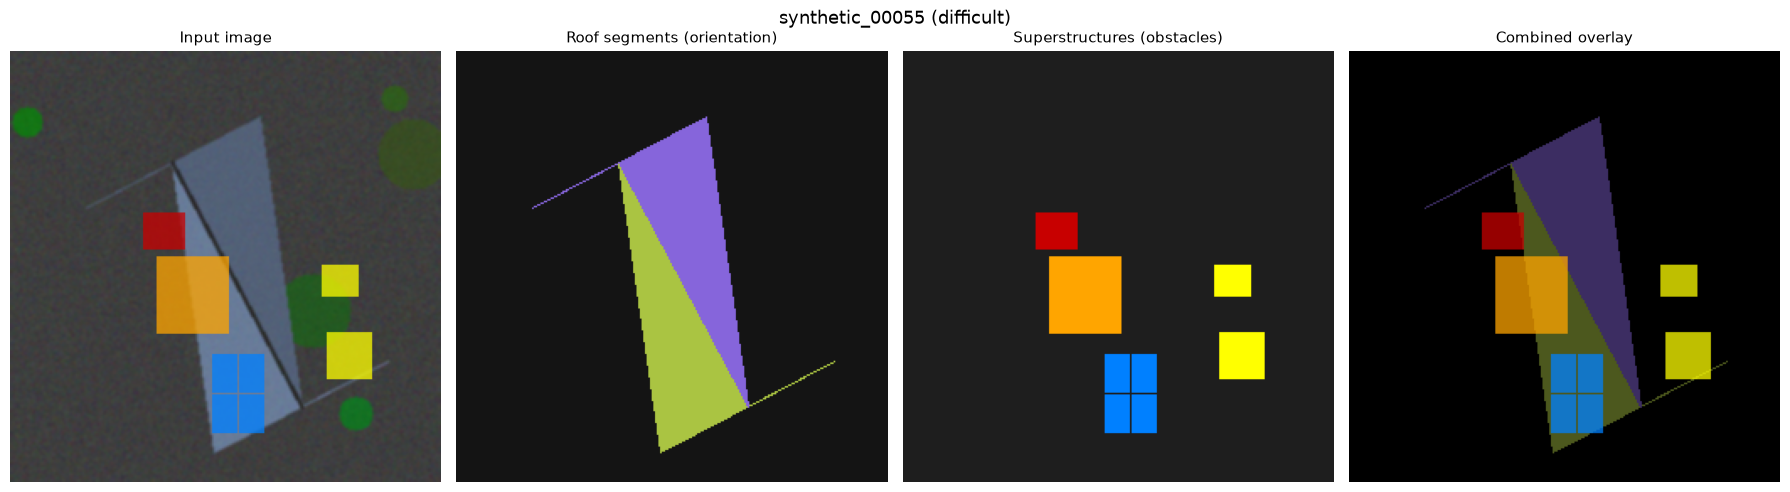

  synthetic_00071: obstacle/roof pixel ratio = 0.435


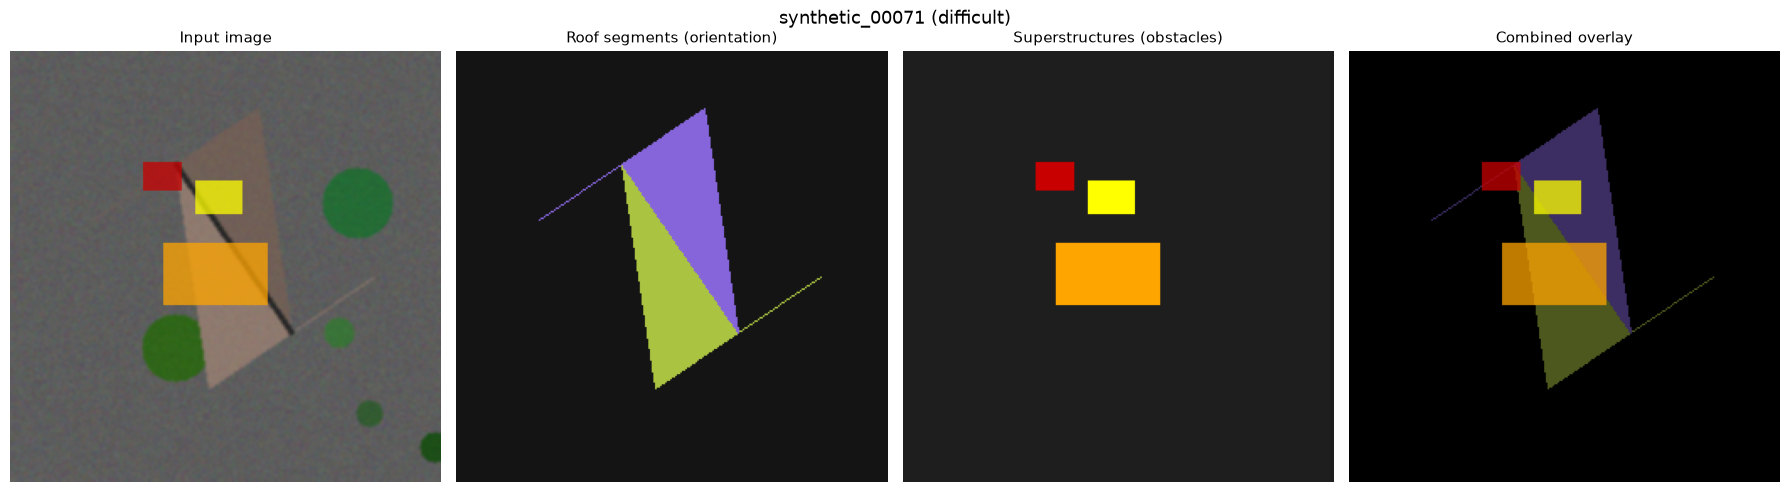

  synthetic_00058: obstacle/roof pixel ratio = 0.424


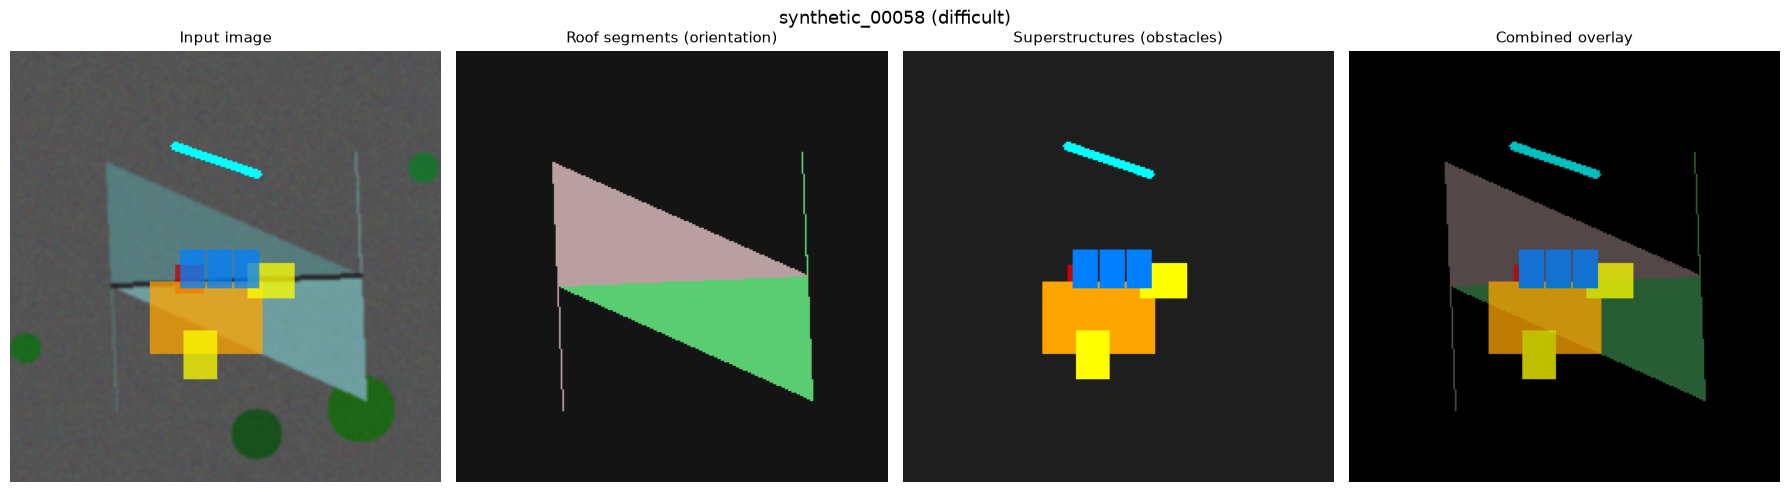

In [7]:
ratios = []
for i in range(len(dataset)):
    item = dataset[i]
    seg = item['segment_mask'].numpy()
    obs = item['superstructure_mask'].numpy()
    roof_px = (seg != 0).sum()
    obs_px = (obs != 0).sum()
    ratios.append((item['sample_id'], obs_px / max(roof_px, 1), i))

ratios.sort(key=lambda r: -r[1])
print('Top 3 most obstacle-dense samples (hardest for usable-area estimation):')
for sample_id, ratio, idx in ratios[:3]:
    print(f'  {sample_id}: obstacle/roof pixel ratio = {ratio:.3f}')
    item = dataset[idx]
    fig = plot_sample_overview(item['image'].permute(1, 2, 0).numpy(), item['segment_mask'].numpy(),
                                item['superstructure_mask'].numpy(), title=f'{sample_id} (difficult)')
    plt.show()